 Data loaded successfully
          ds        y
0 2007-12-10 9.590761
1 2007-12-11 8.519590
2 2007-12-12 8.183677
3 2007-12-13 8.072467
4 2007-12-14 7.893572


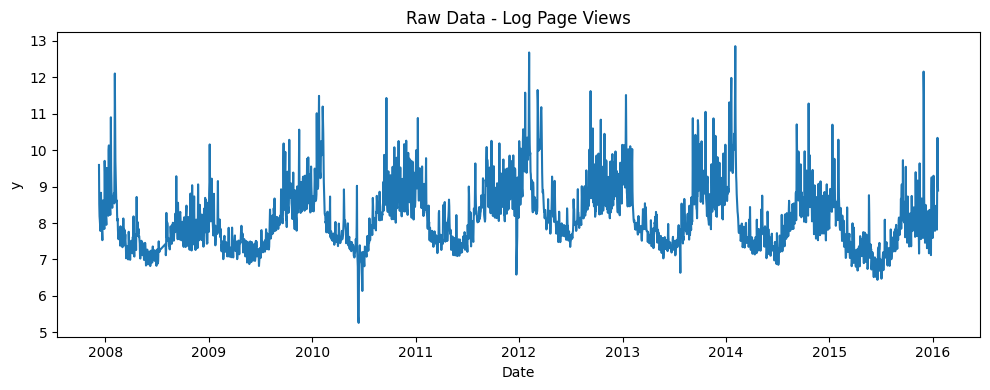

DEBUG:cmdstanpy:input tempfile: /tmp/tmpjdjtmxit/35x2dkhc.json
DEBUG:cmdstanpy:input tempfile: /tmp/tmpjdjtmxit/qt9lg0oj.json
DEBUG:cmdstanpy:idx 0
DEBUG:cmdstanpy:running CmdStan, num_threads: None
DEBUG:cmdstanpy:CmdStan args: ['/usr/local/lib/python3.12/dist-packages/prophet/stan_model/prophet_model.bin', 'random', 'seed=66998', 'data', 'file=/tmp/tmpjdjtmxit/35x2dkhc.json', 'init=/tmp/tmpjdjtmxit/qt9lg0oj.json', 'output', 'file=/tmp/tmpjdjtmxit/prophet_modeli55p_ktu/prophet_model-20251009130650.csv', 'method=optimize', 'algorithm=lbfgs', 'iter=10000']
13:06:50 - cmdstanpy - INFO - Chain [1] start processing
INFO:cmdstanpy:Chain [1] start processing
13:06:51 - cmdstanpy - INFO - Chain [1] done processing
INFO:cmdstanpy:Chain [1] done processing


 Prophet model trained successfully.

Forecast sample:
             ds     yhat  yhat_lower  yhat_upper
3265 2017-01-15 8.210097    7.497825    8.947963
3266 2017-01-16 8.535122    7.852160    9.259119
3267 2017-01-17 8.322549    7.605816    8.992836
3268 2017-01-18 8.155179    7.425819    8.858821
3269 2017-01-19 8.167136    7.420355    8.900485


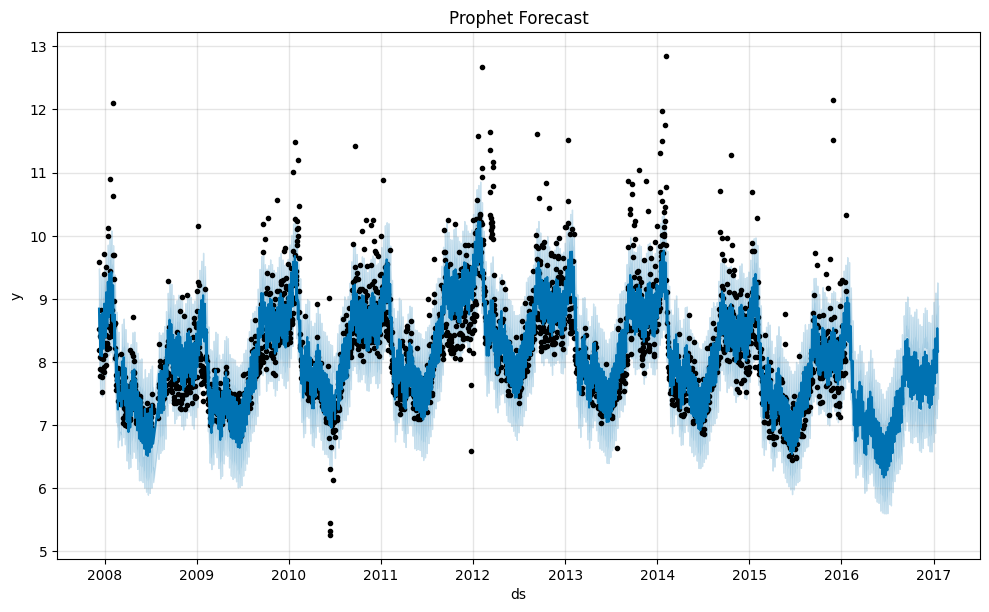

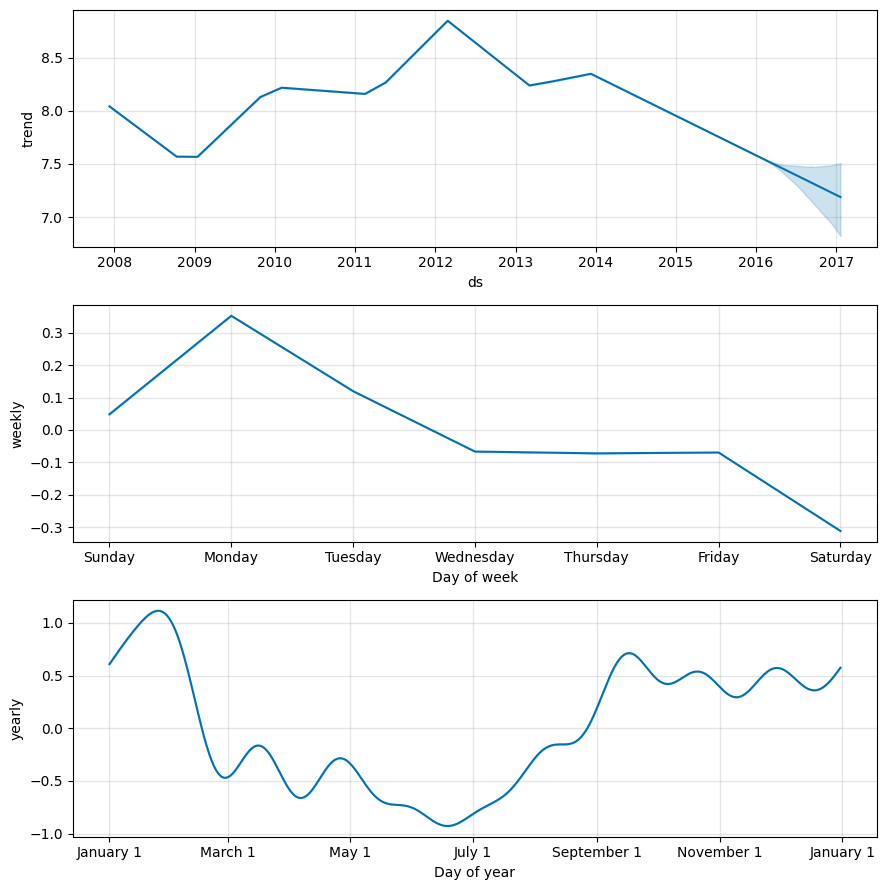

 Model and forecast saved successfully.

Running cross-validation (may take 1–2 minutes)...


INFO:prophet:Making 9 forecasts with cutoffs between 2011-02-10 00:00:00 and 2015-01-20 00:00:00


  0%|          | 0/9 [00:00<?, ?it/s]

DEBUG:cmdstanpy:input tempfile: /tmp/tmpjdjtmxit/wlea0aef.json
DEBUG:cmdstanpy:input tempfile: /tmp/tmpjdjtmxit/rihjhq9k.json
DEBUG:cmdstanpy:idx 0
DEBUG:cmdstanpy:running CmdStan, num_threads: None
DEBUG:cmdstanpy:CmdStan args: ['/usr/local/lib/python3.12/dist-packages/prophet/stan_model/prophet_model.bin', 'random', 'seed=97710', 'data', 'file=/tmp/tmpjdjtmxit/wlea0aef.json', 'init=/tmp/tmpjdjtmxit/rihjhq9k.json', 'output', 'file=/tmp/tmpjdjtmxit/prophet_modelqdvbeqxh/prophet_model-20251009130656.csv', 'method=optimize', 'algorithm=lbfgs', 'iter=10000']
13:06:56 - cmdstanpy - INFO - Chain [1] start processing
INFO:cmdstanpy:Chain [1] start processing
13:06:57 - cmdstanpy - INFO - Chain [1] done processing
INFO:cmdstanpy:Chain [1] done processing
DEBUG:cmdstanpy:input tempfile: /tmp/tmpjdjtmxit/amuxa0e2.json
DEBUG:cmdstanpy:input tempfile: /tmp/tmpjdjtmxit/rtsw4v1v.json
DEBUG:cmdstanpy:idx 0
DEBUG:cmdstanpy:running CmdStan, num_threads: None
DEBUG:cmdstanpy:CmdStan args: ['/usr/local/

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
from prophet import Prophet
from prophet.diagnostics import cross_validation, performance_metrics
import pickle
import numpy as np
import warnings
warnings.filterwarnings("ignore")

# --- 1) Load data ---
url = "https://raw.githubusercontent.com/facebook/prophet/main/examples/example_wp_log_peyton_manning.csv"
df = pd.read_csv(url)
df['ds'] = pd.to_datetime(df['ds'])
print(" Data loaded successfully")
print(df.head())

# --- 2) Visualize raw series ---
plt.figure(figsize=(10,4))
plt.plot(df['ds'], df['y'])
plt.title('Raw Data - Log Page Views')
plt.xlabel('Date')
plt.ylabel('y')
plt.tight_layout()
plt.show()

# --- 3) Build & fit the Prophet model ---
m = Prophet(
    yearly_seasonality=True,
    weekly_seasonality=True,
    daily_seasonality=False,
    changepoint_prior_scale=0.05
)
m.fit(df)
print(" Prophet model trained successfully.")

# --- 4) Create future dataframe and forecast ---
periods = 365  # forecast for 1 year ahead
future = m.make_future_dataframe(periods=periods)
forecast = m.predict(future)

print("\nForecast sample:")
print(forecast[['ds', 'yhat', 'yhat_lower', 'yhat_upper']].tail())

# --- 5) Plot forecast ---
fig1 = m.plot(forecast)
plt.title('Prophet Forecast')
plt.show()

# --- 6) Plot components (trend, seasonality) ---
fig2 = m.plot_components(forecast)
plt.show()

# --- 7) Save model and forecast ---
with open('prophet_model.pkl', 'wb') as f:
    pickle.dump(m, f)
forecast.to_csv('prophet_forecast.csv', index=False)
print(" Model and forecast saved successfully.")

# --- 8) Cross-validation (optional) ---
print("\nRunning cross-validation (may take 1–2 minutes)...")
df_cv = cross_validation(m, initial='1095 days', period='180 days', horizon='365 days')
df_p = performance_metrics(df_cv)
print("\n Cross-validation metrics:")
print(df_p.head())

# --- 9) JULY 4: Predicted vs Actual Analysis ---
print("\n July 4 Predictions vs Actual\n")

# Add date parts
df['year'] = df['ds'].dt.year
df['month'] = df['ds'].dt.month
df['day'] = df['ds'].dt.day

# Get actuals for July 4
actual_july4 = df[(df['month'] == 7) & (df['day'] == 4)][['ds', 'y', 'year']]
actual_july4 = actual_july4.rename(columns={'y': 'actual'})

# Get predictions for July 4
forecast['year'] = forecast['ds'].dt.year
forecast['month'] = forecast['ds'].dt.month
forecast['day'] = forecast['ds'].dt.day
pred_july4 = forecast[(forecast['month'] == 7) & (forecast['day'] == 4)][['ds', 'yhat', 'yhat_lower', 'yhat_upper', 'year']]
pred_july4 = pred_july4.rename(columns={'yhat': 'predicted'})

# Merge both
merged = pd.merge(pred_july4, actual_july4, on='year', how='left', suffixes=('_pred', '_actual'))
merged = merged[['year', 'ds_pred', 'predicted', 'yhat_lower', 'yhat_upper', 'ds_actual', 'actual']].sort_values('year')

# Display comparison
print(merged.to_string(index=False))

# Evaluate only where actuals exist
eval_df = merged.dropna(subset=['actual']).copy()
if not eval_df.empty:
    eval_df['abs_error'] = (eval_df['predicted'] - eval_df['actual']).abs()
    mae = eval_df['abs_error'].mean()
    mse = ((eval_df['predicted'] - eval_df['actual'])**2).mean()
    rmse = np.sqrt(mse)
    print("\n📈 Evaluation for years with actuals:")
    print(f"MAE: {mae:.6f}")
    print(f"RMSE: {rmse:.6f}")
else:
    print("\n No actual July 4 records found in dataset for comparison.")

# --- 10) Plot July 4 Predicted vs Actual ---
plt.figure(figsize=(8,5))
plt.scatter(merged['year'], merged['predicted'], label='Predicted (yhat)', marker='o')
plt.scatter(merged['year'], merged['actual'], label='Actual (y)', marker='x', color='red')
plt.plot(merged['year'], merged['predicted'], linestyle='--', linewidth=1)
plt.errorbar(merged['year'], merged['predicted'],
             yerr=[merged['predicted'] - merged['yhat_lower'], merged['yhat_upper'] - merged['predicted']],
             fmt='none', capsize=4, alpha=0.6)
plt.xlabel('Year (July 4)')
plt.ylabel('y (log views)')
plt.title('July 4: Predicted vs Actual (Prophet)')
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

# --- 11) Save July 4 comparison ---
merged.to_csv('july4_predicted_vs_actual.csv', index=False)
print("\n Saved July 4 predictions vs actuals to 'july4_predicted_vs_actual.csv'.")
